# Benchmark H2O — Rigid Scan (SP), R = 3.00–5.80 Å
### Perbandingan Kurva Energi Potensial (PES) O-H pada H₂O di Jarak Jauh
**Metode:** HF, B3LYP (DFT), CASSCF(8,6), CASCI approx. (maxiter=1), FCI(10,7) — basis set STO-3G

---
**Catatan metodologi:**
- Scan menggunakan metode **Rigid Scan (Single Point/SP)**: jarak O-H pertama di-scan dari 3.00–5.80 Å, koordinat H₂ difiksasi.
- Geometri menggunakan hasil optimasi Avogadro yang ditranslasikan ke origin:
  `O(0,0,0), H(0,0,R), H(-0.8604, 0.2094, 0.3936)`
- **CASCI approx.** menggunakan `maxiter=1` (bukan CASCI murni karena `maxiter=0` menyebabkan I/O error di ORCA 6.0.1).
- **FCI(10,7)** = CASSCF dengan semua elektron (nel=10) dan semua orbital (norb=7) dalam basis STO-3G → referensi eksak dalam basis ini.
- Di jarak jauh (R > 3.0 Å), ikatan O-H sudah putus → sistem mendekati 2 atom terpisah → energi CASSCF/FCI hampir konstan (flat).


In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Hasil Simulasi (ORCA, Relaxed Scan)

In [2]:
import numpy as np

# ── Jarak ikatan O-H (Å) — 16 titik, R = 3.00–5.80 Å ──
R = list(np.linspace(3.00, 5.80, 16))

# ── HF/STO-3G ──
E_HF = [-74.522741335425, -74.511025615074, -74.501870938705, -74.494647910807,
        -74.488860546872, -74.484146206714, -74.480224195092, -74.476884007591,
        -74.473987053838, -74.471422941534, -74.469122384289, -74.467028937947,
        -74.465108571875, -74.463333782714, -74.461684743731, -74.460146289424]

# ── B3LYP/STO-3G ──
E_DFT = [-74.978349035693, -74.971811585530, -74.967052753684, -74.963618510205,
         -74.961155444478, -74.959375771587, -74.958044566464, -74.957016418424,
         -74.956209915630, -74.955566109252, -74.955037999623, -74.954590096830,
         -74.954194236378, -74.953834119120, -74.953501929942, -74.953193119852]

# ── CASSCF(8,6)/STO-3G ──
E_CASSCF = [-74.853800879561, -74.853673685229, -74.853619967175, -74.853598086866,
            -74.853589520413, -74.853586324794, -74.853585175362, -74.853584775695,
            -74.853584635491, -74.853584582274, -74.853584559208, -74.853584547937,
            -74.853584542228, -74.853584539370, -74.853584538008, -74.853584537416]

# ── CASCI approx. (maxiter=1)/STO-3G ──
E_CASCI = [-74.296148421311, -74.285965953945, -74.276550394586, -74.267930711833,
           -74.260074810727, -74.252921925902, -74.246401565473, -74.240443776501,
           -74.234984044355, -74.229965081437, -74.225336979471, -74.221056608023,
           -74.217086751965, -74.213395233416, -74.209954120995, -74.206739059067]

# ── FCI(10,7)/STO-3G (Referensi Eksak) ──
E_FCI = [-74.853813368661, -74.853686145562, -74.853632413302, -74.853610531439,
         -74.853601967099, -74.853598758771, -74.853597608561, -74.853597208674,
         -74.853597068376, -74.853597015195, -74.853596992176, -74.853596980964,
         -74.853596975308, -74.853596972493, -74.853596971160, -74.853596970589]

print(f'Jumlah titik R : {len(R)}')
print(f'Range R        : {R[0]:.2f} – {R[-1]:.2f} Å')
print(f'Step R         : {R[1]-R[0]:.4f} Å')


Jumlah titik R : 16
Range R        : 3.00 – 5.80 Å
Step R         : 0.1867 Å


## 2. Hitung Error Relatif

Referensi: **FCI(10,7)** — energi eksak dalam basis set STO-3G.


In [3]:
# ── Referensi: FCI ──
e_ref        = np.array(E_FCI)
error_hf     = np.abs(np.array(E_HF)     - e_ref)
error_dft    = np.abs(np.array(E_DFT)    - e_ref)
error_casscf = np.abs(np.array(E_CASSCF) - e_ref)
error_casci  = np.abs(np.array(E_CASCI)  - e_ref)

CA = 0.0016  # Chemical Accuracy (Hartree)

print('Error rata-rata vs FCI:')
print(f'  HF     : {np.mean(error_hf):.6e} Ha')
print(f'  B3LYP  : {np.mean(error_dft):.6e} Ha')
print(f'  CASSCF : {np.mean(error_casscf):.6e} Ha')
print(f'  CASCI  : {np.mean(error_casci):.6e} Ha')


Error rata-rata vs FCI:
  HF     : 3.728549e-01 Ha
  B3LYP  : 1.059149e-01 Ha
  CASSCF : 1.244071e-05 Ha
  CASCI  : 6.108099e-01 Ha


## 3. Plot Kurva Energi Potensial (PES) dan Error


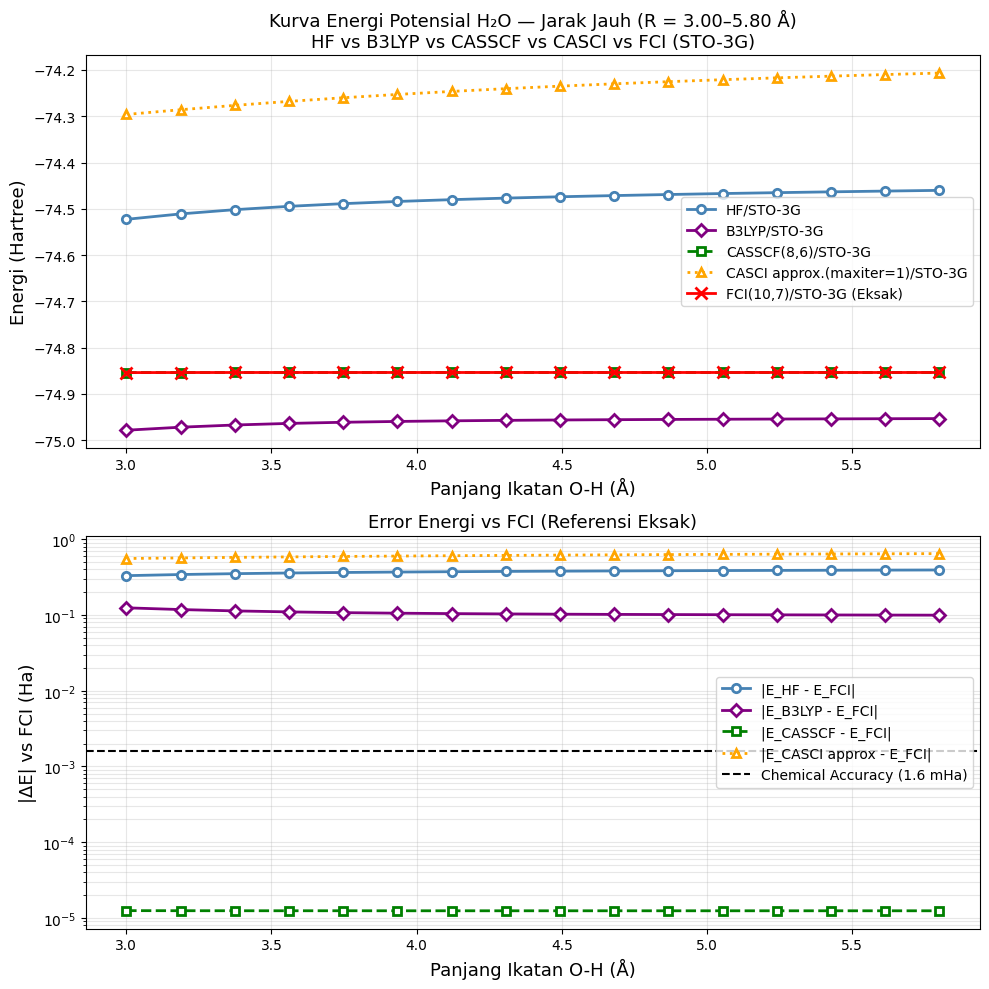

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# ── Plot 1: PES ──
ax1.plot(R, E_HF,     'o-',  color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,    'D-',  color='purple',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF, 's--', color='green',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(8,6)/STO-3G')
ax1.plot(R, E_CASCI,  '^:',  color='orange',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI approx.(maxiter=1)/STO-3G')
ax1.plot(R, E_FCI,    'x-',  color='red',       linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI(10,7)/STO-3G (Eksak)')

ax1.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂O — Jarak Jauh (R = 3.00–5.80 Å)\n'
              'HF vs B3LYP vs CASSCF vs CASCI vs FCI (STO-3G)',
              fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Error vs FCI ──
ax2.semilogy(R, error_hf     + 1e-10, 'o-',  color='steelblue', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF - E_FCI|')
ax2.semilogy(R, error_dft    + 1e-10, 'D-',  color='purple',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(R, error_casscf + 1e-10, 's--', color='green',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF - E_FCI|')
ax2.semilogy(R, error_casci  + 1e-10, '^:',  color='orange',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI approx - E_FCI|')
ax2.axhline(y=CA, color='black', linestyle='--',
            linewidth=1.5, label='Chemical Accuracy (1.6 mHa)')
ax2.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=13)
ax2.set_ylabel('|ΔE| vs FCI (Ha)', fontsize=13)
ax2.set_title('Error Energi vs FCI (Referensi Eksak)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('PES_H2O_SP2_3to5.8.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# ── Ringkasan Energi Elektronik ──
print('='*65)
print('RINGKASAN ENERGI H₂O (STO-3G), R = 3.00–5.80 Å')
print('='*65)
print(f'{"Metode":<22} {"E (R=3.00 Å)":>15} {"E (R=5.80 Å)":>15} {"ΔE (Ha)":>10}')
print('-'*65)
datasets = {
    'HF':            E_HF,
    'B3LYP':         E_DFT,
    'CASSCF(8,6)':   E_CASSCF,
    'CASCI approx.': E_CASCI,
    'FCI(10,7)':     E_FCI,
}
for nama, E in datasets.items():
    delta = abs(E[-1] - E[0])
    print(f'{nama:<22} {E[0]:>15.6f} {E[-1]:>15.6f} {delta:>10.6f}')
print('='*65)
print('\nCatatan: ΔE = |E(5.80) - E(3.00)|')
print('CASSCF/FCI ΔE sangat kecil → sudah flat (bond dissociation terjadi sepenuhnya)')


RINGKASAN ENERGI H₂O (STO-3G), R = 3.00–5.80 Å
Metode                    E (R=3.00 Å)    E (R=5.80 Å)    ΔE (Ha)
-----------------------------------------------------------------
HF                          -74.522741      -74.460146   0.062595
B3LYP                       -74.978349      -74.953193   0.025156
CASSCF(8,6)                 -74.853801      -74.853585   0.000216
CASCI approx.               -74.296148      -74.206739   0.089409
FCI(10,7)                   -74.853813      -74.853597   0.000216

Catatan: ΔE = |E(5.80) - E(3.00)|
CASSCF/FCI ΔE sangat kecil → sudah flat (bond dissociation terjadi sepenuhnya)
